In [7]:
from tensorflow.keras import backend as K
K.clear_session()

In [8]:
!pip install rarfile

In [9]:
import os
import pandas as pd
import gdown
import rarfile
import shutil
from PIL import Image
# Download the RAR file
url = 'https://drive.google.com/uc?id=1QpuuKjhpL_9KiNp-tqdcahBPmX5ojgS0'
#https://drive.google.com/file/d/1QpuuKjhpL_9KiNp-tqdcahBPmX5ojgS0/view?usp=drive_link
output_rar = '/content/Plant_Drone_Dataset.rar'
gdown.download(url, output_rar, quiet=False)
# Extract the RAR file
with rarfile.RarFile(output_rar, 'r') as rar_ref:
    rar_ref.extractall('/content')

Downloading...
From (original): https://drive.google.com/uc?id=1QpuuKjhpL_9KiNp-tqdcahBPmX5ojgS0
From (redirected): https://drive.google.com/uc?id=1QpuuKjhpL_9KiNp-tqdcahBPmX5ojgS0&confirm=t&uuid=30698843-5910-4e50-bc89-03915346799e
To: /content/Plant_Drone_Dataset.rar
100%|██████████| 358M/358M [00:02<00:00, 140MB/s]


In [10]:
# Path to the extracted dataset folder

dataset = '/content/Plant_Drone_Dataset'

In [11]:
#AlexNet

from keras.models import Model
from keras.layers import Input, Conv2D, MaxPooling2D, Activation, Flatten, Dense, Dropout, BatchNormalization

def alexnet(input_shape=(224, 224, 3), num_classes=4):
    inputs = Input(shape=input_shape)

    # 1st Convolutional Layer
    x = Conv2D(filters=96, kernel_size=(11, 11), strides=(4, 4), padding='valid')(inputs)
    x = BatchNormalization()(x)
    x = Activation('swish')(x)
    x = MaxPooling2D(pool_size=(3, 3), strides=(2, 2))(x)

    # 2nd Convolutional Layer
    x = Conv2D(filters=256, kernel_size=(5, 5), padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('swish')(x)
    x = MaxPooling2D(pool_size=(3, 3), strides=(2, 2))(x)

    # 3rd Convolutional Layer
    x = Conv2D(filters=384, kernel_size=(3, 3), padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('swish')(x)

    # 4th Convolutional Layer
    x = Conv2D(filters=384, kernel_size=(3, 3), padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('swish')(x)

    # 5th Convolutional Layer
    x = Conv2D(filters=256, kernel_size=(3, 3), padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('swish')(x)
    x = MaxPooling2D(pool_size=(3, 3), strides=(2, 2))(x)

    # Flatten the output of the last convolutional layer
    x = Flatten()(x)

    # 1st Fully Connected Layer
    x = Dense(4096)(x)
    x = BatchNormalization()(x)
    x = Activation('swish')(x)
    x = Dropout(0.5)(x)

    # 2nd Fully Connected Layer
    x = Dense(4096)(x)
    x = BatchNormalization()(x)
    x = Activation('swish')(x)
    x = Dropout(0.5)(x)

    # Output Layer
    outputs = Dense(num_classes, activation='softmax')(x)

    # Build Model
    alexnet_model = Model(inputs=inputs, outputs=outputs)

    # Compile the model
    alexnet_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    return alexnet_model

# Example: Building and summarizing the AlexNet model
model = alexnet(input_shape=(224, 224, 3), num_classes=4)  # For example, 4 classes
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 54, 54, 96)     │        34,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 54, 54, 96)     │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 54, 54, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 26, 26, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 26, 26, 256)    │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 26, 26, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 26, 26, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 384)    │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 12, 384)    │         1,536 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 12, 12, 384)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 12, 12, 384)    │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 12, 12, 384)    │         1,536 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 12, 12, 384)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 256)    │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4096)           │    26,218,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 4096)           │        16,384 │
│ (BatchNormalization)            │                        │             

 Total params: 46,801,668 (178.53 MB)

 Trainable params: 46,782,532 (178.46 MB)

 Non-trainable params: 19,136 (74.75 KB)

Found 5742 images belonging to 4 classes.
Found 957 images belonging to 4 classes.
Found 1595 images belonging to 4 classes.
Epoch 1/30


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


180/180 ━━━━━━━━━━━━━━━━━━━━ 36s 103ms/step - accuracy: 0.9454 - loss: 0.1513 - val_accuracy: 0.2424 - val_loss: 16.3918
Epoch 2/30
180/180 ━━━━━━━━━━━━━━━━━━━━ 12s 68ms/step - accuracy: 0.9996 - loss: 0.0014 - val_accuracy: 0.2424 - val_loss: 17.1994
Epoch 3/30
180/180 ━━━━━━━━━━━━━━━━━━━━ 12s 69ms/step - accuracy: 0.9977 - loss: 0.0095 - val_accuracy: 0.2424 - val_loss: 23.3179
Epoch 4/30
180/180 ━━━━━━━━━━━━━━━━━━━━ 12s 68ms/step - accuracy: 0.9896 - loss: 0.0380 - val_accuracy: 0.7722 - val_loss: 1.4800
Epoch 5/30
180/180 ━━━━━━━━━━━━━━━━━━━━ 13s 75ms/step - accuracy: 0.9983 - loss: 0.0039 - val_accuracy: 0.6395 - val_loss: 4.3230
Epoch 6/30
180/180 ━━━━━━━━━━━━━━━━━━━━ 13s 74ms/step - accuracy: 1.0000 - loss: 1.7021e-04 - val_accuracy: 0.9498 - val_loss: 0.2953
Epoch 7/30
180/180 ━━━━━━━━━━━━━━━━━━━━ 12s 68ms/step - accuracy: 0.9911 - loss: 0.0303 - val_accuracy: 0.9122 - val_loss: 0.6782
Epoch 8/30
180/180 ━━━━━━━━━━━━━━━━━━━━ 12s 67ms/step - accuracy: 0.9995 - loss: 8.3873e-04 -

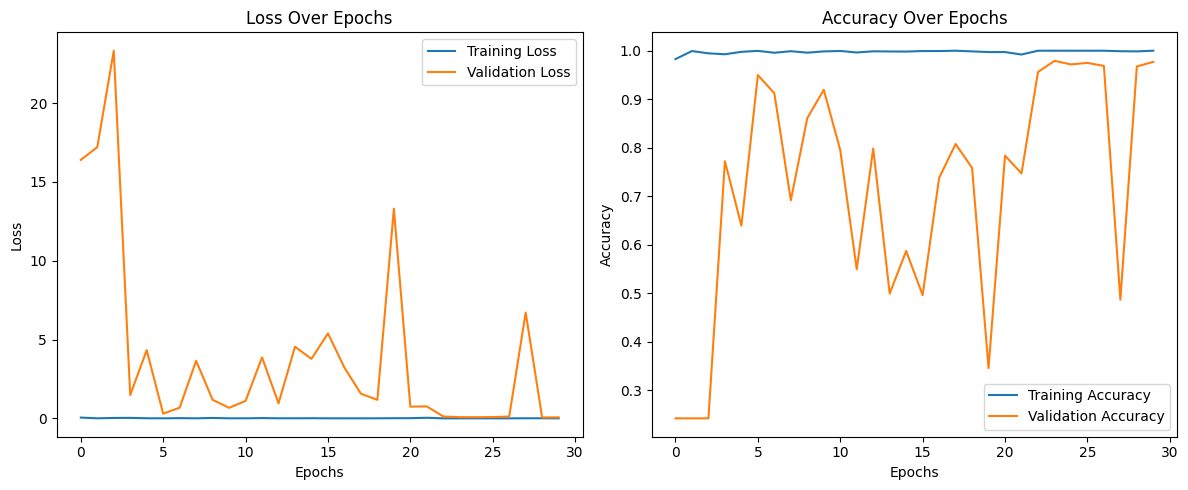

50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 62ms/step

Performance on Test Data [Using Model_2-swish]
Precision: 1.0
Recall: 1.0
F1 Score: 1.0
Accuracy: 1.0
Confusion Matrix:
                                 acacia modesta (phulai)  \
acacia modesta (phulai)                             348   
ailanthus altissima (Bahishti)                        0   
bauhinia variegata (kachnar)                          0   
pinus roxburghii (chir)                               0   

                                ailanthus altissima (Bahishti)  \
acacia modesta (phulai)                                      0   
ailanthus altissima (Bahishti)                             406   
bauhinia variegata (kachnar)                                 0   
pinus roxburghii (chir)                                      0   

                                bauhinia variegata (kachnar)  \
acacia modesta (phulai)                                    0   
ailanthus altissima (Bahishti)                             0   
bauhinia variegata 

In [12]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import (
    Input, Conv2D, BatchNormalization, Activation, MaxPooling2D, Add,
    GlobalAveragePooling2D, Flatten, Dense
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import KFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
)

# Directory for the dataset
data_dir = dataset

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.0001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])


# ImageDataGenerators
train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

# Data generators for training, validation, and testing
train_generator = train_datagen.flow_from_directory(
    os.path.join(data_dir, 'Train'),
    target_size=(224, 224),
    batch_size=32,
    class_mode='sparse',
    shuffle=True
)

val_generator = val_datagen.flow_from_directory(
    os.path.join(data_dir, 'Validate'),
    target_size=(224, 224),
    batch_size=32,
    class_mode='sparse',
    shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    os.path.join(data_dir, 'Test'),
    target_size=(224, 224),
    batch_size=32,
    class_mode='sparse',
    shuffle=False
)

# Training the model
history = model.fit(train_generator, epochs=30, validation_data=val_generator)

# Plot training results
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

# Helper function to evaluate the model on given test generator
def evaluate_model(test_generator, model, classes, title="Performance"):
    y_test_pred = model.predict(test_generator)
    y_test_pred = np.argmax(y_test_pred, axis=1)

    precision = precision_score(test_generator.labels, y_test_pred, average='weighted')
    recall = recall_score(test_generator.labels, y_test_pred, average='weighted')
    f1 = f1_score(test_generator.labels, y_test_pred, average='weighted')
    accuracy = accuracy_score(test_generator.labels, y_test_pred)

    print(f"\n{title}")
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1 Score:", f1)
    print("Accuracy:", accuracy)

    # Display the confusion matrix
    confusion = confusion_matrix(test_generator.labels, y_test_pred)
    confusion_df = pd.DataFrame(confusion, index=classes, columns=classes)
    print("Confusion Matrix:\n", confusion_df)

# Test the model on the test set
evaluate_model(test_generator, model, ['acacia modesta (phulai)', 'ailanthus altissima (Bahishti)', 'bauhinia variegata (kachnar)', 'pinus roxburghii (chir)'], title="Performance on Test Data [Using Model_2-swish]")


50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 121ms/step
Confusion Matrix:
                                 acacia modesta (phulai)  \
acacia modesta (phulai)                             348   
ailanthus altissima (Bahishti)                        0   
bauhinia variegata (kachnar)                          0   
pinus roxburghii (chir)                               0   

                                ailanthus altissima (Bahishti)  \
acacia modesta (phulai)                                      0   
ailanthus altissima (Bahishti)                             406   
bauhinia variegata (kachnar)                                 0   
pinus roxburghii (chir)                                      0   

                                bauhinia variegata (kachnar)  \
acacia modesta (phulai)                                    0   
ailanthus altissima (Bahishti)                             0   
bauhinia variegata (kachnar)                             406   
pinus roxburghii (chir)                                  

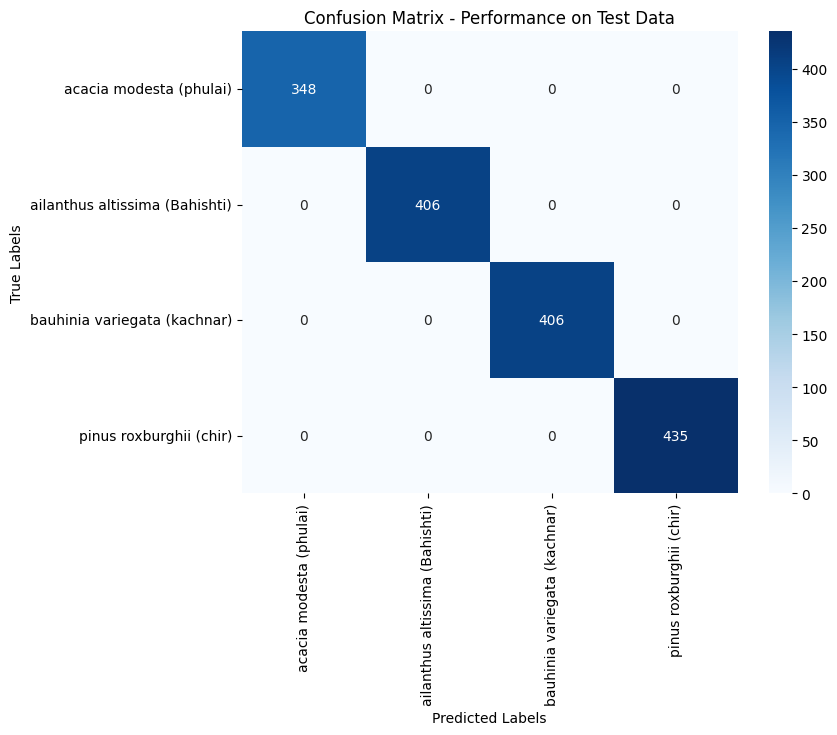

In [13]:
# Add this import at the beginning of your code
import seaborn as sns

# Generate and display the heatmap for the confusion matrix
labels = [
    'acacia modesta (phulai)', 'ailanthus altissima (Bahishti)', 'bauhinia variegata (kachnar)', 'pinus roxburghii (chir)'
]

# Predict on test data
y_test_pred = model.predict(test_generator)
y_test_pred_classes = np.argmax(y_test_pred, axis=1)

# Calculate the confusion matrix
confusion = confusion_matrix(test_generator.labels, y_test_pred_classes)

# Convert confusion matrix to a DataFrame for better readability
confusion_df = pd.DataFrame(confusion, index=labels, columns=labels)

# Print the confusion matrix
print("Confusion Matrix:\n", confusion_df)

# Plot confusion matrix as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_df, annot=True, cmap='Blues', fmt='g')
plt.title('Confusion Matrix - Performance on Test Data')
plt.ylabel('True Labels')
plt.xlabel('Predicted Labels')
plt.show()